<h1>Correlation zweier Signale:</h1>

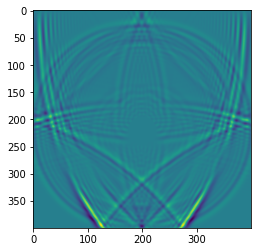

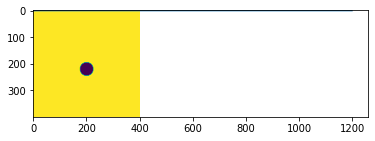

In [7]:
import numpy
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot
import wellen_simulation

heigth = 400
width = 400 #m
d_x = 1 #m
d_y = 1 #m
time = 0.6 #s
d_t = 0.0005

n_x = int(width/d_x)
n_y = int(heigth/d_y)
n_t = int(time/d_t)
seitenverhältnis = n_y/n_x


v = 1000 * numpy.ones((n_y, n_x))
r = 25
for x in range(n_x):
    for y in range(n_y):   
        a = 220
        b = 200
        h = a/d_y - y
        w = b/d_x -x
        if numpy.sqrt((h)**2 + (w)**2) <= r:
            v[y, x] = 0

u = numpy.zeros((n_y, n_x, n_t))

gauss = wellen_simulation.point_source(amplitude_gauss=10, mu_x=0.5, mu_y=0.1, sigma=0.007, n_x=n_x, n_y=n_y)
u[:, :, 0] = gauss
u[:, :, 1] = gauss


u = wellen_simulation.wellen_simulieren_ohne_wände(u, v, n_t, d_t, d_x, d_y)
matplotlib.pyplot.imshow(u[:,:,-1])
matplotlib.pyplot.show()
matplotlib.pyplot.imshow(v)

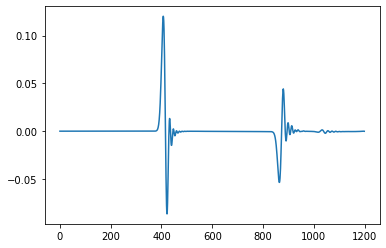

In [8]:
matplotlib.pyplot.plot(u[0,0,:])

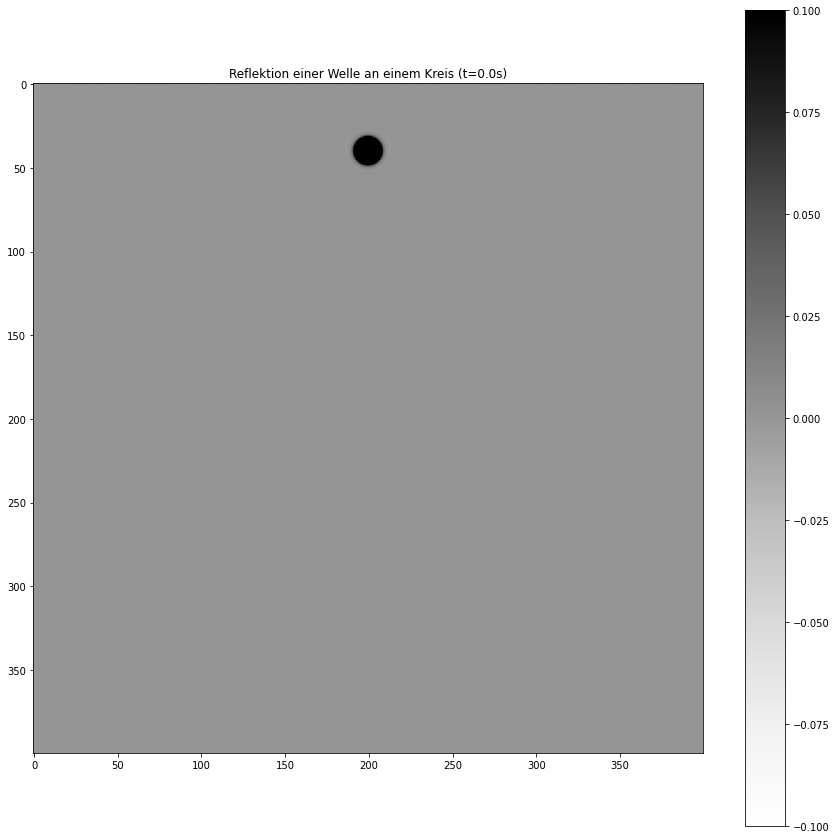

In [9]:
# Funktion für die Animation
def update(frame):
    print(frame, end='\r')
    im.set_array(u[:,:,frame])
    cbar.mappable.set_array(u[:, :, frame])
    cbar.mappable.set_clim(-0.1,0.1)
    ax.set_title("Reflektion einer Welle an einem Kreis (t=" + str(numpy.round(frame/n_t, 2)) + "s)")
    return im,
 
# Erstelle das Figure-Objekt und die Axes-Objekte
skalierung = 15
fig, ax = plt.subplots(figsize=(skalierung, skalierung*seitenverhältnis))
im = ax.imshow(u[:,:,-1], cmap='Greys')
cbar = plt.colorbar(im)

# Erstelle die Animation
ani = FuncAnimation(fig, update, frames=n_t, interval=50, blit=True)

# Zeige das Video an
plt.show()
ani.save('korrelation.mp4', fps=120, extra_args=['-vcodec', 'libx264'])

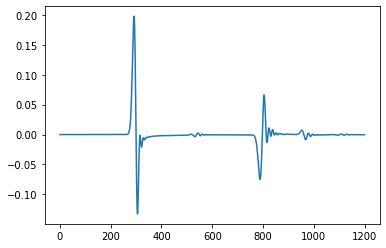

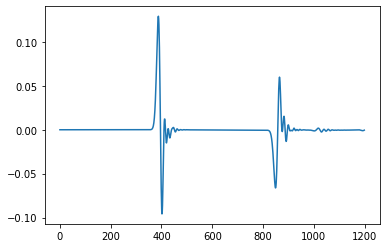

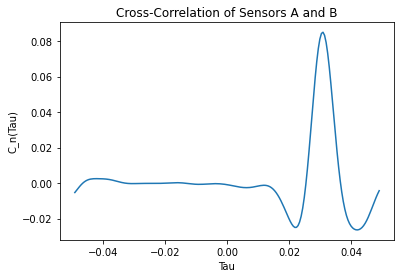

49
1000.0


In [150]:
a = 340
signal_a = u[0,a,:]
b = 389
signal_b = u[0,b,:]
L = b-a
c = v[0,0]
tau_max = L/c
tau_discrete_max = int(tau_max/d_t)

def correlation_n(sig1, sig2, tau, t, k_max):
    fenster1 = sig1[t:t+k_max]
    fenster2 = sig2[t+tau:t+k_max+tau]
    
    return fenster1*fenster2

def correlation(sig1, sig2, tau_max, t_0, k_max):
    correlation = numpy.zeros((2*tau_max))
    for i in range(2*tau_max):
        tau = -tau_max+i
        correlation[i] = numpy.sum(correlation_n(sig1, sig2, tau, t_0, k_max))
    return correlation

matplotlib.pyplot.plot(signal_a)
matplotlib.pyplot.show()
matplotlib.pyplot.plot(signal_b)
matplotlib.pyplot.show()
matplotlib.pyplot.plot(numpy.linspace(-tau_max,tau_max,2*tau_discrete_max),correlation(signal_a,signal_b, tau_discrete_max, 700, 400))
plt.xlabel('Tau')
plt.ylabel('C_n(Tau)')
plt.title('Cross-Correlation of Sensors A and B')
matplotlib.pyplot.show()
print(L)
print(c)

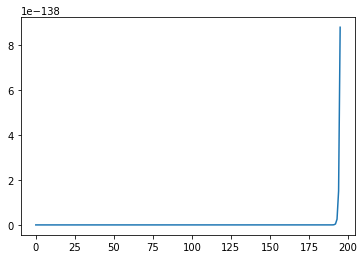

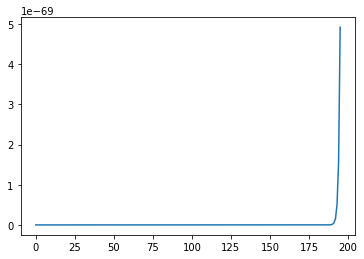

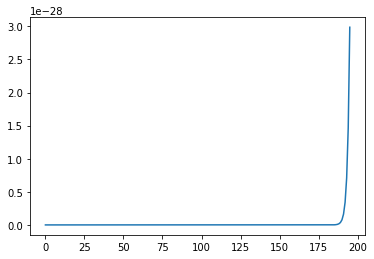

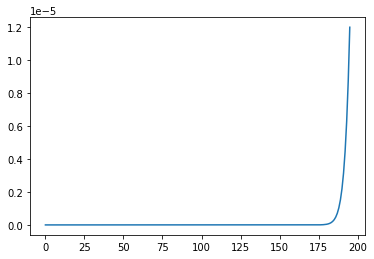

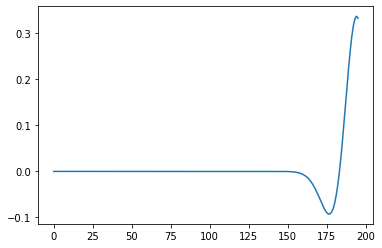

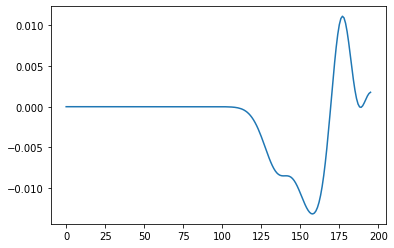

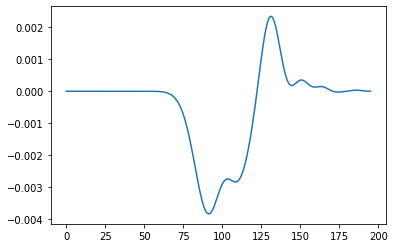

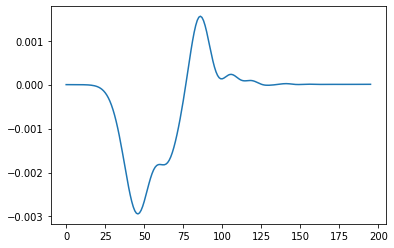

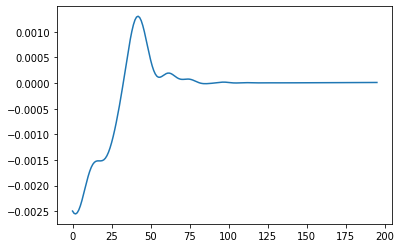

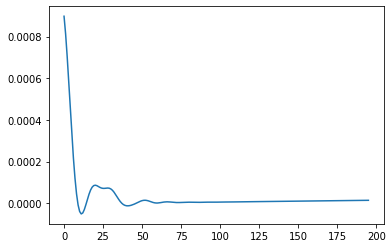

In [165]:
for t in numpy.linspace(tau_discrete_max,tau_discrete_max+400,10):
    matplotlib.pyplot.plot(correlation(signal_a,signal_b, tau_discrete_max, int(t), 40))
    matplotlib.pyplot.show()
